A multi-agent AI system that accepts a food image as input and produces structured nutritional analysis, a personalized recipe, and meal advice — delivered as both a terminal summary and a generated HTML report.

In [28]:
import langchain
import langchain_ollama
import langchain_core
import langgraph
from importlib.metadata import version

print("LangChain version      :", langchain.__version__)
print("LangChain-Ollama version:", langchain_ollama.__version__)
print("LangChain-Core version  :", langchain_core.__version__)
print("LangGraph version       :", version("langgraph"))

LangChain version      : 1.3.1
LangChain-Ollama version: 1.1.0
LangChain-Core version  : 1.4.0
LangGraph version       : 1.2.0


In [29]:
import requests

response = requests.get("http://localhost:11434/api/tags")
models = response.json()

print("Ollama is running ✅")
print("\nAvailable models:")
for model in models["models"]:
    print(f"  - {model['name']}")

Ollama is running ✅

Available models:
  - llava:latest
  - llama3.2:latest
  - qwen2.5:3b
  - qwen3.5:2b
  - gemma3:270m


In [30]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="llama3.2",
    base_url="http://localhost:11434"
)

response = llm.invoke("Say hello in one sentence.")
print(response.content)

Hello!


In [31]:
from typing import TypedDict, Optional
from pydantic import BaseModel

# --- Structured Output for Agent 1 ---
# Instead of nutrition_data: str (raw string, unreliable)
# Agent 1 now returns a typed Pydantic object
class NutritionData(BaseModel):
    food_name: str          # what food was detected
    calories: int           # estimated calories
    protein: float          # grams of protein
    carbs: float            # grams of carbohydrates
    fat: float              # grams of fat
    ingredients: list[str]  # detected ingredients
    health_score: int       # 1-10 (drives the conditional edge)
    is_healthy: bool        # True if health_score >= 5

# --- Enhanced Agent State ---
class AgentState(TypedDict):
    # Input
    image_path: str                      # path to food image

    # Agent outputs (typed now, not raw strings)
    nutrition_data: Optional[NutritionData]  # structured output from Agent 1
    recipe: str                              # output of Agent 2
    meal_advice: str                         # output of Agent 3

    # Routing & control
    health_status: str                   # "healthy" or "unhealthy" — drives conditional edge
    warning_message: str                 # filled if food is unhealthy

    # Observability
    agent1_tokens: int                   # token usage for Agent 1
    agent2_tokens: int                   # token usage for Agent 2
    agent3_tokens: int                   # token usage for Agent 3
    agent1_time: float                   # execution time for Agent 1
    agent2_time: float                   # execution time for Agent 2
    agent3_time: float                   # execution time for Agent 3

    # Human checkpoint
    human_feedback: str                  # user's input after reviewing recipe

    # Final output
    html_report_path: str                # path to generated HTML file

Agent 1: Nutritional Analyst

In [32]:
import base64
import time
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage

# --- Vision Model ---
vision_llm = ChatOllama(
    model="llava",
    base_url="http://localhost:11434"
)

# --- Agent 1 Node ---
def nutrition_analyst(state: AgentState) -> AgentState:
    print("\n🔍 Agent 1 — Nutrition Analyst running...")
    start_time = time.time()

    # --- Load and encode image to base64 ---
    with open(state["image_path"], "rb") as f:
        image_data = base64.b64encode(f.read()).decode("utf-8")

    # --- Prompt asking for structured JSON output ---
    prompt = """You are a professional nutrition analyst. Analyze this food image and respond ONLY with a valid JSON object, no extra text, no markdown, no backticks.

    The JSON must follow this exact structure:
    {
        "food_name": "name of the food",
        "calories": estimated calories as integer,
        "protein": grams of protein as float,
        "carbs": grams of carbohydrates as float,
        "fat": grams of fat as float,
        "ingredients": ["ingredient1", "ingredient2"],
        "health_score": score from 1 to 10 as integer,
        "is_healthy": true or false
    }

    Rules:
    - health_score >= 5 means is_healthy = true
    - health_score < 5 means is_healthy = false
    - Be realistic with estimates
    - ingredients list should have at least 3 items
    """

    # --- Call vision model with image ---
    message = HumanMessage(content=[
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{image_data}"
            }
        },
        {
            "type": "text",
            "text": prompt
        }
    ])

    response = vision_llm.invoke([message])

    # --- Parse response into Pydantic model ---
    import json
    try:
        # clean response in case model adds any extra text
        raw = response.content.strip()
        # find the JSON block
        start = raw.find("{")
        end = raw.rfind("}") + 1
        json_str = raw[start:end]
        data = json.loads(json_str)
        nutrition = NutritionData(**data)
    except Exception as e:
        print(f"⚠️ Parsing error: {e}")
        print(f"Raw response: {response.content}")
        # fallback safe default
        nutrition = NutritionData(
            food_name="Unknown Food",
            calories=500,
            protein=10.0,
            carbs=50.0,
            fat=20.0,
            ingredients=["unknown"],
            health_score=5,
            is_healthy=True
        )

    # --- Observability ---
    elapsed = round(time.time() - start_time, 2)
    tokens = response.usage_metadata.get("total_tokens", 0) if response.usage_metadata else 0

    print(f"    Detected: {nutrition.food_name}")
    print(f"    Health Score: {nutrition.health_score}/10")
    print(f"    Time: {elapsed}s |  Tokens: {tokens}")

    return {
        **state,
        "nutrition_data": nutrition.model_dump(),
        "health_status": "healthy" if nutrition.is_healthy else "unhealthy",
        "agent1_time": elapsed,
        "agent1_tokens": tokens
    }

Step 2 — Conditional Edge + Warning Node + Human Checkpoint

In [33]:
import time
from typing import Literal
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt

# ----------------------------------------------------------------
# ROUTER FUNCTION — reads health_status from state
# returns a string that maps to the next node
# Literal documents valid destinations (per LangGraph docs)
# ----------------------------------------------------------------
def health_router(state: AgentState) -> Literal["recipe_creator", "warning_node"]:
    if state["health_status"] == "healthy":
        return "recipe_creator"
    else:
        return "warning_node"

# ----------------------------------------------------------------
# WARNING NODE — runs only when food is unhealthy
# skips recipe, goes directly to meal advisor
# ----------------------------------------------------------------
def warning_node(state: AgentState) -> AgentState:
    print("\n⚠️  Warning Node — Unhealthy food detected!")

    nutrition = state["nutrition_data"]  # now a plain dict
    warning = (
        f"WARNING: {nutrition['food_name']} has a low health score "
        f"({nutrition['health_score']}/10). "
        f"Estimated {nutrition['calories']} calories with high "
        f"fat content ({nutrition['fat']}g). "
        f"Recipe generation skipped. Proceeding to meal advice."
    )
    print(f"   {warning}")

    return {
        **state,
        "warning_message": warning,
        "recipe": "No recipe generated — food flagged as unhealthy."
    }

# ----------------------------------------------------------------
# HUMAN CHECKPOINT NODE — pauses graph, waits for user input
# Uses LangGraph's interrupt() — requires MemorySaver checkpointer
# ----------------------------------------------------------------
def human_checkpoint(state: AgentState) -> AgentState:
    print("\n⏸️  Human Checkpoint — Review the recipe above.")
    
    # interrupt() pauses the graph here and surfaces a message to the user
    # graph resumes when .invoke() is called again with the user's response
    user_feedback = interrupt(
        {
            "message": "Review the recipe above. Any dietary restrictions or changes?",
            "current_recipe": state["recipe"],
            "nutrition": state["nutrition_data"].food_name
        }
    )
    
    print(f"   ✅ Feedback received: {user_feedback}")
    
    return {
        **state,
        "human_feedback": user_feedback
    }

Step 3 — Agent 2: Recipe Creator

In [34]:
# ----------------------------------------------------------------
# Text LLM — llama3.2 (already defined earlier, reusing it)
# ----------------------------------------------------------------
text_llm = ChatOllama(
    model="llama3.2",
    base_url="http://localhost:11434",
    temperature=0  # deterministic output for reliability
)

# ----------------------------------------------------------------
# AGENT 2 NODE — Recipe Creator
# receives structured NutritionData from state
# returns a recipe string back into state
# ----------------------------------------------------------------
def recipe_creator(state: AgentState) -> AgentState:
    print("\n👨‍🍳 Agent 2 — Recipe Creator running...")
    start_time = time.time()

    nutrition = state["nutrition_data"]  # plain dict

    prompt = f"""You are a professional chef and nutritionist.

Based on the following nutrition analysis, create a healthy recipe:

Food detected : {nutrition["food_name"]}
Calories      : {nutrition["calories"]} kcal
Protein       : {nutrition["protein"]}g
Carbohydrates : {nutrition["carbs"]}g
Fat           : {nutrition["fat"]}g
Ingredients   : {", ".join(nutrition["ingredients"])}
Health Score  : {nutrition["health_score"]}/10

Create a detailed recipe with:
1. Recipe name
2. Ingredients with quantities
3. Step-by-step cooking instructions
4. Estimated cooking time
5. One healthy tip

Keep it practical and easy to follow.
"""

    response = text_llm.invoke(prompt)

    elapsed = round(time.time() - start_time, 2)
    tokens = response.usage_metadata.get("total_tokens", 0) if response.usage_metadata else 0

    print(f"   ✅ Recipe generated for: {nutrition['food_name']}")
    print(f"   ⏱️  Time: {elapsed}s | 🪙 Tokens: {tokens}")

    return {
        **state,
        "recipe"      : response.content,
        "agent2_time" : elapsed,
        "agent2_tokens": tokens
    }

In [40]:
# ----------------------------------------------------------------
# AGENT 3 NODE — Meal Advisor
# receives nutrition_data + recipe + human_feedback from state
# this is the FINAL agent — gives personalized meal advice
# ----------------------------------------------------------------
def meal_advisor(state: AgentState) -> AgentState:
    print("\n🥗 Agent 3 — Meal Advisor running...")
    start_time = time.time()

    nutrition = state["nutrition_data"]  # plain dict
    recipe    = state.get("recipe", "No recipe generated.")
    feedback  = state.get("human_feedback", "No additional feedback provided.")
    warning   = state.get("warning_message", "")

    if warning:
        # unhealthy path
        prompt = f"""You are a professional dietitian and meal advisor.

A food item was flagged as unhealthy:

Food          : {nutrition["food_name"]}
Health Score  : {nutrition["health_score"]}/10
Calories      : {nutrition["calories"]} kcal
Warning       : {warning}

Please provide:
1. Why this food is unhealthy
2. What health risks it poses if consumed regularly
3. Three healthier alternatives to this food
4. A simple meal plan for the rest of the day to compensate

Be direct, helpful and practical.
"""
    else:
        # healthy path
        prompt = f"""You are a professional dietitian and meal advisor.

A food item was analyzed and a recipe was created:

Food          : {nutrition["food_name"]}
Health Score  : {nutrition["health_score"]}/10
Calories      : {nutrition["calories"]} kcal
Protein       : {nutrition["protein"]}g
Carbs         : {nutrition["carbs"]}g
Fat           : {nutrition["fat"]}g

Recipe Created:
{recipe}

User Feedback : {feedback}

Please provide:
1. Nutritional benefits of this meal
2. Best time of day to consume it
3. How it fits into a balanced daily diet
4. Any modifications based on user feedback: {feedback}
5. One important dietary tip

Be practical, encouraging and specific.
"""

    response = text_llm.invoke(prompt)

    elapsed = round(time.time() - start_time, 2)
    tokens = response.usage_metadata.get("total_tokens", 0) if response.usage_metadata else 0

    print(f"   ✅ Meal advice generated")
    print(f"   ⏱️  Time: {elapsed}s | 🪙 Tokens: {tokens}")

    return {
        **state,
        "meal_advice"  : response.content,
        "agent3_time"  : elapsed,
        "agent3_tokens": tokens
    }

In [41]:
def generate_html_report(state: AgentState) -> AgentState:
    print("\n📄 Generating HTML Report...")

    nutrition  = state["nutrition_data"]  # now a plain dict
    recipe     = state.get("recipe", "No recipe generated.")
    advice     = state.get("meal_advice", "No advice generated.")
    warning    = state.get("warning_message", "")
    feedback   = state.get("human_feedback", "None provided.")

    # total observability summary
    total_tokens = (
        state.get("agent1_tokens", 0) +
        state.get("agent2_tokens", 0) +
        state.get("agent3_tokens", 0)
    )
    total_time = round(
        state.get("agent1_time", 0) +
        state.get("agent2_time", 0) +
        state.get("agent3_time", 0), 2
    )

    # health score color — green if healthy, red if not
    score_color  = "#2ecc71" if nutrition["is_healthy"] else "#e74c3c"
    status_label = "✅ Healthy" if nutrition["is_healthy"] else "⚠️ Unhealthy"

    # recipe or warning section — depends on which path was taken
    middle_section = ""
    if warning:
        middle_section = f"""
        <div class="section warning-box">
            <h2>⚠️ Health Warning</h2>
            <p>{warning}</p>
        </div>
        """
    else:
        recipe_html = recipe.replace("\n", "<br>")
        middle_section = f"""
        <div class="section">
            <h2>👨‍🍳 Generated Recipe</h2>
            <div class="content-box">{recipe_html}</div>
        </div>
        <div class="section">
            <h2>💬 Your Feedback</h2>
            <p class="feedback">{feedback}</p>
        </div>
        """

    advice_html = advice.replace("\n", "<br>")

    html_content = f"""<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Meal Analysis Report — {nutrition["food_name"]}</title>
    <style>
        body {{
            font-family: 'Segoe UI', sans-serif;
            background-color: #f4f6f8;
            color: #2c3e50;
            margin: 0;
            padding: 20px;
        }}
        .container {{
            max-width: 860px;
            margin: auto;
            background: white;
            border-radius: 12px;
            box-shadow: 0 4px 20px rgba(0,0,0,0.1);
            padding: 40px;
        }}
        h1 {{
            color: #2c3e50;
            border-bottom: 3px solid #3498db;
            padding-bottom: 10px;
        }}
        h2 {{ color: #3498db; }}
        .nutrition-grid {{
            display: grid;
            grid-template-columns: repeat(3, 1fr);
            gap: 16px;
            margin: 20px 0;
        }}
        .nutrition-card {{
            background: #eaf4fb;
            border-radius: 8px;
            padding: 16px;
            text-align: center;
        }}
        .nutrition-card .value {{
            font-size: 1.8em;
            font-weight: bold;
            color: #2980b9;
        }}
        .nutrition-card .label {{
            font-size: 0.85em;
            color: #7f8c8d;
            margin-top: 4px;
        }}
        .health-badge {{
            display: inline-block;
            background-color: {score_color};
            color: white;
            padding: 6px 16px;
            border-radius: 20px;
            font-weight: bold;
            margin-bottom: 16px;
        }}
        .section {{ margin-top: 32px; }}
        .content-box {{
            background: #f9f9f9;
            border-left: 4px solid #3498db;
            padding: 16px;
            border-radius: 6px;
            line-height: 1.7;
        }}
        .warning-box {{
            background: #fdecea;
            border-left: 4px solid #e74c3c;
            padding: 16px;
            border-radius: 6px;
        }}
        .feedback {{
            font-style: italic;
            color: #555;
            background: #f0f0f0;
            padding: 10px;
            border-radius: 6px;
        }}
        .metrics {{
            display: flex;
            gap: 24px;
            background: #eafaf1;
            padding: 16px;
            border-radius: 8px;
            margin-top: 32px;
        }}
        .metric {{
            text-align: center;
        }}
        .metric .val {{
            font-size: 1.4em;
            font-weight: bold;
            color: #27ae60;
        }}
        .metric .lbl {{
            font-size: 0.8em;
            color: #7f8c8d;
        }}
        footer {{
            margin-top: 40px;
            text-align: center;
            font-size: 0.8em;
            color: #aaa;
        }}
    </style>
</head>
<body>
<div class="container">
    <h1>🍽️ Meal Analysis Report</h1>
    <p><strong>Food Detected:</strong> {nutrition["food_name"]}</p>
    <div class="health-badge">{status_label} — Score: {nutrition["health_score"]}/10</div>

    <div class="section">
        <h2>📊 Nutrition Breakdown</h2>
        <div class="nutrition-grid">
            <div class="nutrition-card">
                <div class="value">{nutrition["calories"]}</div>
                <div class="label">Calories (kcal)</div>
            </div>
            <div class="nutrition-card">
                <div class="value">{nutrition["protein"]}g</div>
                <div class="label">Protein</div>
            </div>
            <div class="nutrition-card">
                <div class="value">{nutrition["carbs"]}g</div>
                <div class="label">Carbohydrates</div>
            </div>
            <div class="nutrition-card">
                <div class="value">{nutrition["fat"]}g</div>
                <div class="label">Fat</div>
            </div>
            <div class="nutrition-card">
                <div class="value">{len(nutrition["ingredients"])}</div>
                <div class="label">Ingredients Found</div>
            </div>
            <div class="nutrition-card">
                <div class="value">{nutrition["health_score"]}/10</div>
                <div class="label">Health Score</div>
            </div>
        </div>
        <p><strong>Ingredients:</strong> {", ".join(nutrition["ingredients"])}</p>
    </div>

    {middle_section}

    <div class="section">
        <h2>🥗 Meal Advice</h2>
        <div class="content-box">{advice_html}</div>
    </div>

    <div class="metrics">
        <div class="metric">
            <div class="val">{state.get("agent1_time", 0)}s</div>
            <div class="lbl">Agent 1 Time</div>
        </div>
        <div class="metric">
            <div class="val">{state.get("agent2_time", 0)}s</div>
            <div class="lbl">Agent 2 Time</div>
        </div>
        <div class="metric">
            <div class="val">{state.get("agent3_time", 0)}s</div>
            <div class="lbl">Agent 3 Time</div>
        </div>
        <div class="metric">
            <div class="val">{total_time}s</div>
            <div class="lbl">Total Time</div>
        </div>
        <div class="metric">
            <div class="val">{total_tokens}</div>
            <div class="lbl">Total Tokens</div>
        </div>
    </div>

    <footer>Generated by Multi-Agent Food Analysis System · LangGraph + LangChain + Ollama</footer>
</div>
</body>
</html>"""

    # write HTML file to disk
    report_path = f"meal_report_{nutrition['food_name'].replace(' ', '_')}.html"
    with open(report_path, "w", encoding="utf-8") as f:
        f.write(html_content)

    print(f"   ✅ HTML report saved → {report_path}")
    print(f"   📊 Total tokens used : {total_tokens}")
    print(f"   ⏱️  Total time taken  : {total_time}s")

    return {
        **state,
        "html_report_path": report_path
    }

In [42]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

# ----------------------------------------------------------------
# STEP 1 — initialize the graph with our state
# ----------------------------------------------------------------
workflow = StateGraph(AgentState)

# ----------------------------------------------------------------
# STEP 2 — add all nodes
# ----------------------------------------------------------------
workflow.add_node("nutrition_analyst",  nutrition_analyst)
workflow.add_node("warning_node",       warning_node)
workflow.add_node("recipe_creator",     recipe_creator)
workflow.add_node("human_checkpoint",   human_checkpoint)
workflow.add_node("meal_advisor",       meal_advisor)
workflow.add_node("generate_html_report", generate_html_report)

# ----------------------------------------------------------------
# STEP 3 — define edges (the flow)
# ----------------------------------------------------------------

# entry point — graph always starts at nutrition_analyst
workflow.add_edge(START, "nutrition_analyst")

# conditional edge — after Agent 1, router decides which path
workflow.add_conditional_edges(
    "nutrition_analyst",   # source node
    health_router,         # router function
    {
        "recipe_creator" : "recipe_creator",   # healthy path
        "warning_node"   : "warning_node"      # unhealthy path
    }
)

# healthy path
workflow.add_edge("recipe_creator",   "human_checkpoint")
workflow.add_edge("human_checkpoint", "meal_advisor")

# unhealthy path — skips recipe and checkpoint, goes straight to advisor
workflow.add_edge("warning_node", "meal_advisor")

# both paths converge here — always generate report at the end
workflow.add_edge("meal_advisor",         "generate_html_report")
workflow.add_edge("generate_html_report", END)

# ----------------------------------------------------------------
# STEP 4 — compile with MemorySaver
# required for human checkpoint interrupt() to work
# ----------------------------------------------------------------
memory = MemorySaver()

app = workflow.compile(checkpointer=memory)

print("✅ Graph compiled successfully!")

✅ Graph compiled successfully!


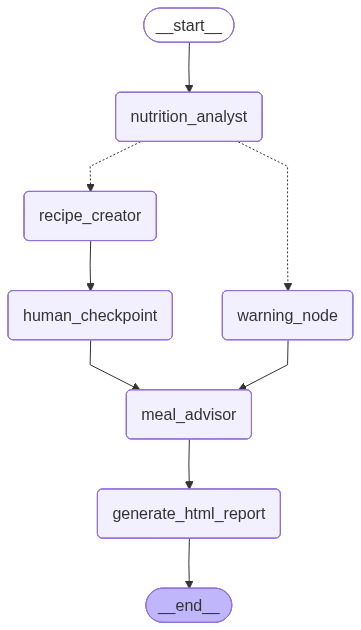

In [38]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [43]:
from langgraph.types import Command

# ----------------------------------------------------------------
# CONFIG — links both invoke calls to same graph run
# ----------------------------------------------------------------
config = {"configurable": {"thread_id": "food_analysis_1"}}

# ----------------------------------------------------------------
# SET YOUR IMAGE PATH
# ----------------------------------------------------------------
initial_state = {
    "image_path"      : r"C:\Users\SANDEEP S\Desktop\sample_food.png",  # replace with your image
    "nutrition_data"  : None,
    "recipe"          : "",
    "meal_advice"     : "",
    "health_status"   : "",
    "warning_message" : "",
    "human_feedback"  : "",
    "html_report_path": "",
    "agent1_tokens"   : 0,
    "agent2_tokens"   : 0,
    "agent3_tokens"   : 0,
    "agent1_time"     : 0.0,
    "agent2_time"     : 0.0,
    "agent3_time"     : 0.0,
}

# ----------------------------------------------------------------
# RUN 1 — runs until human checkpoint (healthy) or fully (unhealthy)
# ----------------------------------------------------------------
print("🚀 Starting pipeline...\n")

result = app.invoke(initial_state, config=config)

# ----------------------------------------------------------------
# CHECK — did the graph pause for human input?
# ----------------------------------------------------------------
if "__interrupt__" in result:
    # show the recipe to the user
    print("\n⏸️  Pipeline paused for your review")
    print("-" * 40)
    print(result["recipe"])
    print("-" * 40)

    # get feedback
    feedback = input("\n💬 Any changes or dietary restrictions? (Enter to skip): ").strip()
    if not feedback:
        feedback = "No changes needed!"

    # RUN 2 — resume graph with feedback
    print("\n▶️  Resuming pipeline...\n")
    result = app.invoke(Command(resume=feedback), config=config)

# ----------------------------------------------------------------
# FINAL OUTPUT
# ----------------------------------------------------------------
nutrition = result["nutrition_data"]
print(f"🍽️  Food         : {nutrition['food_name']}")
print(f"❤️  Health Score : {nutrition['health_score']}/10")
print(f"🔥 Calories      : {nutrition['calories']} kcal")
print(f"💪 Protein       : {nutrition['protein']}g")
print(f"🌾 Carbs         : {nutrition['carbs']}g")
print(f"🧈 Fat           : {nutrition['fat']}g")

print(f"\n📊 Observability:")
print(f"   Agent 1 → {result.get('agent1_time', 0)}s | {result.get('agent1_tokens', 0)} tokens")
print(f"   Agent 2 → {result.get('agent2_time', 0)}s | {result.get('agent2_tokens', 0)} tokens")
print(f"   Agent 3 → {result.get('agent3_time', 0)}s | {result.get('agent3_tokens', 0)} tokens")

print(f"\n📄 Report saved → {result.get('html_report_path')}")
print("=" * 50)

🚀 Starting pipeline...


🔍 Agent 1 — Nutrition Analyst running...
    Detected: Cheeseburger
    Health Score: 4/10
    Time: 4.51s |  Tokens: 928

⚠️  Warning Node — Unhealthy food detected!

🥗 Agent 3 — Meal Advisor running...
   ✅ Meal advice generated
   ⏱️  Time: 12.0s | 🪙 Tokens: 557

📄 Generating HTML Report...
   ✅ HTML report saved → meal_report_Cheeseburger.html
   📊 Total tokens used : 1485
   ⏱️  Total time taken  : 16.51s
🍽️  Food         : Cheeseburger
❤️  Health Score : 4/10
🔥 Calories      : 800 kcal
💪 Protein       : 50.5g
🌾 Carbs         : 70.0g
🧈 Fat           : 60.0g

📊 Observability:
   Agent 1 → 4.51s | 928 tokens
   Agent 2 → 0.0s | 0 tokens
   Agent 3 → 12.0s | 557 tokens

📄 Report saved → meal_report_Cheeseburger.html
